# AdExSurrogate Verification

Verifies the `AdExSurrogate` channel along two axes:

1. **Forward equivalence** — with sufficiently sharp surrogate slope, `AdExSurrogate` reproduces the spike trains of the standard `AdEx` channel on the three Naud parameter sets.
2. **Backward gradient existence** — for a parameter that only enters the dynamics through the spike condition (`v_threshold`), `AdEx` returns a structurally zero gradient while `AdExSurrogate` returns a finite, non-zero one for all three surrogate variants (sigmoid / exponential / SuperSpike).

Companion plot: forward and backward shapes of the three surrogate kernels vs the hard threshold.

Uses the local Jaxley fork at `3_jaxley/`, installed via `pip install -e 3_jaxley/` from the project root. No `git clone` or `sys.path` munging needed.

In [7]:
import jax
import jax.numpy as jnp
from jax import grad, value_and_grad

import numpy as np
import matplotlib.pyplot as plt

import jaxley as jx
from jaxley.channels import AdEx, AdExSurrogate
from jaxley.channels.non_capacitive.spike import (
    _heaviside_with_sigmoid_surrogate,
    _heaviside_with_exponential_surrogate,
    _heaviside_with_superspike_surrogate,
)

In [8]:
NAUD_PARAMETERS = {
    "tonic": {
        "C_m": 200, "g_L": 10, "E_L": -70, "v_T": -50, "delta_T": 2,
        "v_reset": -58, "v_threshold": 0, "tau_w": 30, "a": 2, "b": 0, "I": 500,
    },
    "adaptation": {
        "C_m": 200, "g_L": 12, "E_L": -70, "v_T": -50, "delta_T": 2,
        "v_reset": -58, "v_threshold": 0, "tau_w": 300, "a": 2, "b": 60, "I": 500,
    },
    "original": {
        "C_m": 281, "g_L": 30, "E_L": -70.6, "v_T": -50.4, "delta_T": 2,
        "v_reset": -70.6, "v_threshold": 20, "tau_w": 144, "a": 4, "b": 80.5, "I": 2500,
    },
}

In [9]:
def geometry_for_capacitance(C_pF, specific_capacitance=1.0):
    C_uF = C_pF * 1e-6
    area_cm2 = C_uF / specific_capacitance
    radius_cm = np.sqrt(area_cm2 / (6.28 * np.pi))
    radius_um = radius_cm * 1e4
    length_um = 3.14 * radius_um
    return radius_um, length_um, area_cm2


def build_cell(channel, params):
    """Build a single-compartment Jaxley cell with the given AdEx-family channel."""
    radius_um, length_um, _ = geometry_for_capacitance(params["C_m"])
    cell = jx.Cell()
    cell.set("radius", radius_um)
    cell.set("length", length_um)
    cell.insert(channel)
    cell.set("capacitance", params["C_m"])
    cell.set("AdEx_g_L", params["g_L"])
    cell.set("AdEx_E_L", params["E_L"])
    cell.set("AdEx_v_T", params["v_T"])
    cell.set("AdEx_delta_T", params["delta_T"])
    cell.set("AdEx_v_threshold", params["v_threshold"])
    cell.set("AdEx_v_reset", params["v_reset"])
    cell.set("AdEx_tau_w", params["tau_w"])
    cell.set("AdEx_a", params["a"])
    cell.set("AdEx_b", params["b"])
    cell.set("v", params["v_reset"])
    cell.record("v")
    cell.record("AdEx_spikes")
    return cell


def run(channel, params, dt_ms=0.025, duration_ms=400.0, t_max_ms=600.0):
    cell = build_cell(channel, params)
    I_nA = params["I"] * params["C_m"] / 1000.0
    cell.stimulate(jx.step_current(0.0, duration_ms, I_nA, dt_ms, t_max=t_max_ms))
    out = jx.integrate(cell, delta_t=dt_ms)
    voltage = np.array(out[0]).flatten()
    spikes = np.array(out[1]).flatten()
    time = np.arange(len(voltage)) * dt_ms
    spike_idx = np.where(spikes > 0.5)[0]
    spike_times = time[spike_idx] if len(spike_idx) else np.array([])
    return time, voltage, spike_times

## Part 1 — Forward equivalence

If the surrogate slope $\beta$ is large enough, the smooth spike indicator $\tilde{H}(v - v_{\text{th}})$ collapses back to the Heaviside step and `AdExSurrogate` should reproduce the spike trains of plain `AdEx` (and therefore Brian2, via the verification of \cref{sec:verification}).

We run both channels on the three Naud parameter sets at $\beta = 25$ and report spike counts and the maximum pair-wise spike-timing difference.

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.


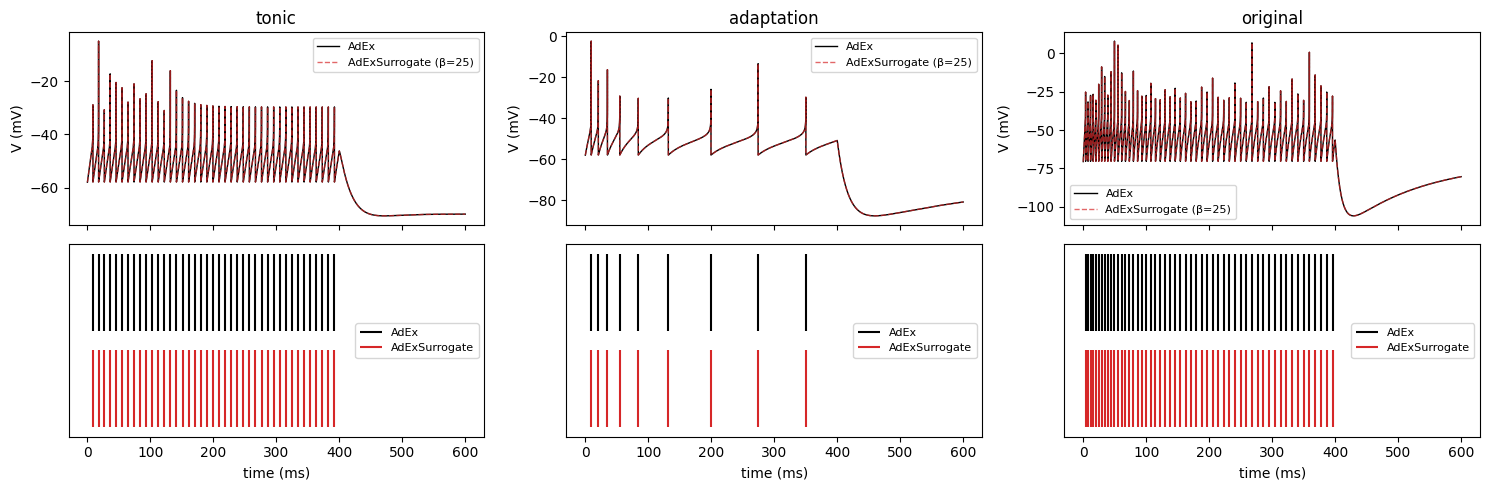


Forward equivalence (sigmoid surrogate, β = 25):
config       #spikes AdEx   #spikes Surr   max Δt (ms) 
tonic        41             41             0.0000      
adaptation   9              9              0.0000      
original     53             53             0.0000      


In [10]:
DT = 0.025
DURATION = 400.0
T_MAX = 600.0
BETA = 25.0

fig, axes = plt.subplots(2, 3, figsize=(15, 5), sharex="col")

summary = []
for col, name in enumerate(NAUD_PARAMETERS):
    p = NAUD_PARAMETERS[name]
    t_h, v_h, st_h = run(AdEx(), p, dt_ms=DT, duration_ms=DURATION, t_max_ms=T_MAX)
    t_s, v_s, st_s = run(
        AdExSurrogate(surrogate_type="sigmoid", surrogate_slope=BETA),
        p, dt_ms=DT, duration_ms=DURATION, t_max_ms=T_MAX,
    )

    n_match = min(len(st_h), len(st_s))
    if n_match:
        max_dt_ms = float(np.max(np.abs(st_h[:n_match] - st_s[:n_match])))
    else:
        max_dt_ms = float("nan")
    summary.append((name, len(st_h), len(st_s), max_dt_ms))

    axes[0, col].plot(t_h, v_h, label="AdEx", color="black", lw=1.0)
    axes[0, col].plot(t_s, v_s, label=f"AdExSurrogate (β={BETA:g})",
                      color="tab:red", lw=1.0, alpha=0.7, linestyle="--")
    axes[0, col].set_title(name)
    axes[0, col].set_ylabel("V (mV)")
    axes[0, col].legend(fontsize=8)

    axes[1, col].vlines(st_h, 0.55, 0.95, color="black", label="AdEx")
    axes[1, col].vlines(st_s, 0.05, 0.45, color="tab:red", label="AdExSurrogate")
    axes[1, col].set_ylim(0, 1)
    axes[1, col].set_yticks([])
    axes[1, col].set_xlabel("time (ms)")
    axes[1, col].legend(fontsize=8, loc="center right")

plt.tight_layout()
plt.show()

print(f"\nForward equivalence (sigmoid surrogate, β = {BETA:g}):")
print(f"{'config':<12} {'#spikes AdEx':<14} {'#spikes Surr':<14} {'max Δt (ms)':<12}")
for name, n_h, n_s, dt_max in summary:
    print(f"{name:<12} {n_h:<14} {n_s:<14} {dt_max:<12.4f}")

## Part 2 — Surrogate kernels

Forward and backward shape of the three surrogate functions, as substituted in place of the Heaviside derivative during back-propagation. The forward pass remains the hard step (left); only the gradient is replaced (right).

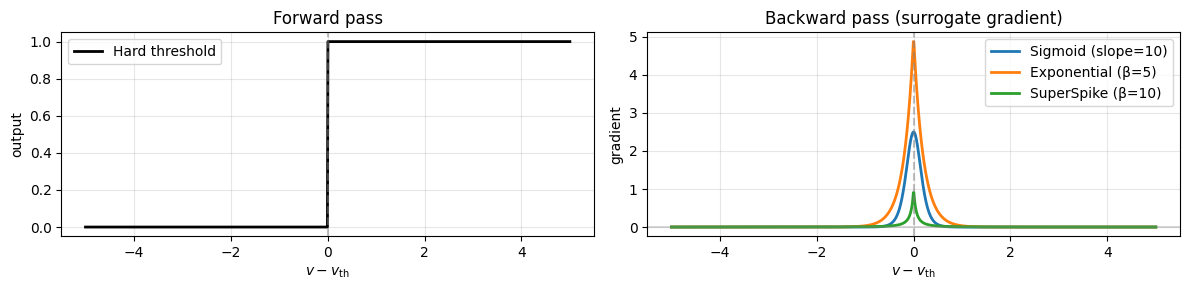

In [11]:
x = jnp.linspace(-5, 5, 1000)

hard = (x >= 0).astype(jnp.float32)

def grad_of(fn, slope_kw):
    return jax.vmap(lambda xv: grad(lambda z: fn(z, **slope_kw))(xv))(x)

g_sig = grad_of(_heaviside_with_sigmoid_surrogate, dict(slope=10.0))
g_exp = grad_of(_heaviside_with_exponential_surrogate, dict(beta=5.0))
g_sup = grad_of(_heaviside_with_superspike_surrogate, dict(beta=10.0))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(x, hard, "k-", lw=2, label="Hard threshold")
axes[0].axvline(0, color="gray", linestyle="--", alpha=0.5)
axes[0].set_title("Forward pass")
axes[0].set_xlabel(r"$v - v_{\text{th}}$")
axes[0].set_ylabel("output")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(x, g_sig, lw=2, label="Sigmoid (slope=10)")
axes[1].plot(x, g_exp, lw=2, label="Exponential (β=5)")
axes[1].plot(x, g_sup, lw=2, label="SuperSpike (β=10)")
axes[1].axvline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].axhline(0, color="gray", linestyle="-", alpha=0.3)
axes[1].set_title("Backward pass (surrogate gradient)")
axes[1].set_xlabel(r"$v - v_{\text{th}}$")
axes[1].set_ylabel("gradient")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/surrogate_gradients_comparison.pdf", dpi=150)
plt.show()

## Part 3 — Gradient existence

The most direct test of the surrogate machinery: pick a parameter that only enters the dynamics through the spike condition and verify that its gradient is zero under `AdEx` and finite under `AdExSurrogate`.

`AdEx_v_threshold` is the cleanest choice — it appears only in `spike_occurred = v >= v_threshold` and in the `jax.lax.select` reset, neither of which carry gradient through their predicate. (`AdEx_v_T` is *not* a clean choice: it also enters the exponential drive `exp((v - v_T)/Δ_T)`, which is differentiable on its own and would yield a non-zero gradient even without any surrogate.)

Loss: $\mathcal{L} = -\sum_t s(t)$ — negative spike count. We expect $\partial\mathcal{L}/\partial v_{\text{th}} > 0$: raising the detection threshold should reduce the spike count and hence increase the loss.

In [12]:
PARAMS = NAUD_PARAMETERS["tonic"]
DT_GRAD = 0.025
DUR_GRAD = 200.0
TMAX_GRAD = 200.0

def make_loss_fn(channel):
    cell = build_cell(channel, PARAMS)
    cell.make_trainable("AdEx_v_threshold")
    I_nA = PARAMS["I"] * PARAMS["C_m"] / 1000.0
    cell.stimulate(jx.step_current(0.0, DUR_GRAD, I_nA, DT_GRAD, t_max=TMAX_GRAD))
    params = cell.get_parameters()

    def loss_fn(p):
        out = jx.integrate(cell, params=p, delta_t=DT_GRAD)
        spikes = out[1]
        return -jnp.sum(spikes)

    return loss_fn, params


def report(label, channel):
    loss_fn, params = make_loss_fn(channel)
    loss_val, grads = value_and_grad(loss_fn)(params)
    g = float(grads[0]["AdEx_v_threshold"][0])
    print(f"{label:<35} loss = {float(loss_val):>10.4f}   d/dv_th = {g:>+.6e}")
    return g


print("Gradient of negative spike count w.r.t. AdEx_v_threshold\n" + "-" * 70)
g_hard = report("AdEx (hard threshold)", AdEx())
g_sig  = report("AdExSurrogate (sigmoid, β=10)",
                AdExSurrogate(surrogate_type="sigmoid", surrogate_slope=10.0))
g_exp  = report("AdExSurrogate (exponential, β=5)",
                AdExSurrogate(surrogate_type="exponential", surrogate_slope=5.0))
g_sup  = report("AdExSurrogate (superspike, β=10)",
                AdExSurrogate(surrogate_type="superspike", surrogate_slope=10.0))

print("-" * 70)
assert g_hard == 0.0, "Expected zero gradient through hard threshold"
for label, g in [("sigmoid", g_sig), ("exponential", g_exp), ("superspike", g_sup)]:
    assert g != 0.0, f"Expected non-zero surrogate gradient ({label})"
    assert g > 0.0, f"Expected positive sign ({label}): higher v_th -> fewer spikes -> higher loss"
print("OK — hard threshold gives zero, all three surrogates give finite positive gradients.")

Gradient of negative spike count w.r.t. AdEx_v_threshold
----------------------------------------------------------------------
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Added 1 external_states. See `.externals` for details.
AdEx (hard threshold)               loss =   -21.0000   d/dv_th = +0.000000e+00
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Added 1 external_states. See `.externals` for details.
AdExSurrogate (sigmoid, β=10)       loss =   -21.0000   d/dv_th = +1.930362e-21
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Added 1 external_states. See `.exte